# Project 3 — Chronic Disease Cost Modelling
## Notebook 2: Exploratory Analysis

**Author:** Amr Thabet  
**Dataset:** 3,000-member synthetic GCC chronic disease cohort (2023–2024)  
**Palette:** Navy #1E566C · Teal #5795A7 · Amber #D4800A  

### Objective
Explore cost patterns, risk drivers, and utilisation behaviour across a UAE/MENA 
health insurance chronic disease cohort. Each chart answers a specific business 
question relevant to GCC payers and RCM teams.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Colour palette — consistent across all projects
NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'
AMBER_LIGHT  = '#F5D98B'
AMBER_MID    = '#E8C040'
AMBER_DARK   = '#B08800'
AMBER_DARKER = '#8A6A00'
Blue         = '#AFC3DD'
Pink         = '#EADCDE'
Green        = '#B7C1B4'

plt.rcParams.update({
    'figure.facecolor':  LIGHT_BG,
    'axes.facecolor':    LIGHT_BG,
    'axes.edgecolor':    GRAY,
    'axes.labelcolor':   NAVY,
    'axes.titlepad':     14,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   NAVY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'text.color':        NAVY,
    'grid.color':        '#D8E4E8',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
})

df = pd.read_csv('../data/chronic_disease_cohort.csv')
print(f"Loaded {len(df):,} members · {df.shape[1]} columns")
df.head()

Loaded 3,000 members · 25 columns


,member_id,year,emirate,nationality,gender,age,plan_tier,payer,condition,bmi,...,er_visits,inpatient_days,outpatient_visits,specialist_visits,total_cost_aed,pharmacy_cost_aed,procedure_cost_aed,consultation_cost_aed,risk_tier,high_cost_flag
0,MBR-00001,2024,Abu Dhabi,Expat - South Asia,Female,33,Basic,Daman (HAAD),Diabetes,35.0,...,2,5,7,5,22859,7714,4122,11023,Low,0
1,MBR-00002,2023,Abu Dhabi,Expat - East Asia,Female,53,Basic,Sukoon Insurance,Diabetes + Cardiac,42.4,...,1,4,2,7,112306,26248,28582,57476,High,1
2,MBR-00003,2023,Dubai,Expat - Arab,Male,50,Basic,BUPA Global,Diabetes + Cardiac,25.9,...,1,2,8,2,69723,19232,23682,26809,High,1
3,MBR-00004,2024,Abu Dhabi,Expat - Arab,Female,59,Premium,AXA Gulf,Hypertension,38.7,...,1,2,10,2,29768,6781,9216,13771,Medium,0
4,MBR-00005,2023,Abu Dhabi,Expat - South Asia,Female,36,Enhanced,AXA Gulf,Cardiac,25.2,...,3,1,15,7,53033,12944,11720,28369,High,0


## Chart 1 — Average cost by chronic condition

**Business question:** Which conditions are driving the most cost across our GCC cohort?

Comorbid conditions (Diabetes + Cardiac, Diabetes + Hypertension) consistently 
outspend single conditions. The amber dashed line is the portfolio average — 
anything above it is a priority intervention cohort for a UAE insurer.

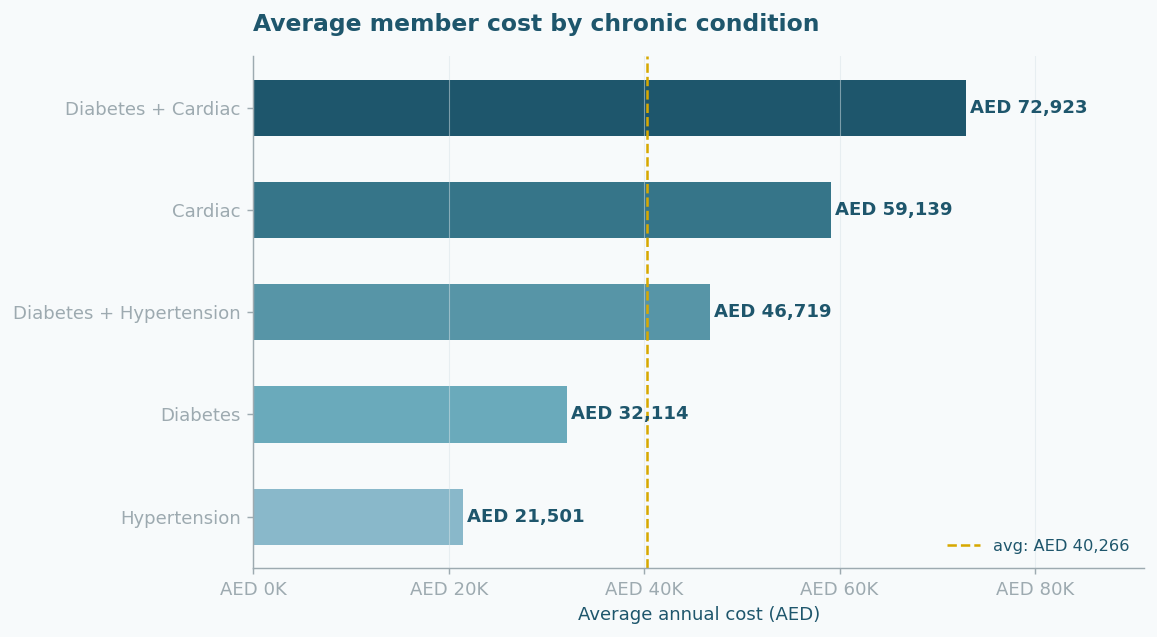

In [124]:
cond_cost = (df.groupby('condition')['total_cost_aed']
               .mean()
               .sort_values(ascending=True))

# Graded — matching Chart 3 palette exactly
grade_colors = [TEAL_LIGHT, '#6AAABB', TEAL, TEAL_DARK, NAVY]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cond_cost.index, cond_cost.values,
               color=grade_colors, height=0.55, edgecolor='none')

for bar, val in zip(bars, cond_cost.values):
    ax.text(val + 400, bar.get_y() + bar.get_height()/2,
            f"AED {val:,.0f}", va='center', fontsize=10, color=NAVY, fontweight='bold')

ax.set_xlabel('Average annual cost (AED)')
ax.set_title('Average member cost by chronic condition', loc='left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1000:.0f}K'))
ax.set_xlim(0, cond_cost.max() * 1.25)
ax.axvline(df['total_cost_aed'].mean(), color=AMBER, linewidth=1.4,
           linestyle='--', label=f'avg: AED {df["total_cost_aed"].mean():,.0f}')
ax.legend(fontsize=9, framealpha=0)
ax.grid(axis='x', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/01_cost_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2 — Average cost by risk tier

**Business question:** How much more does a high-risk member cost compared to a low-risk member?

This is the core financial case for risk stratification programmes in UAE health insurance.
The cost gap between Low and High risk directly quantifies the ROI of early intervention —
identifying and managing high-risk members before they escalate.

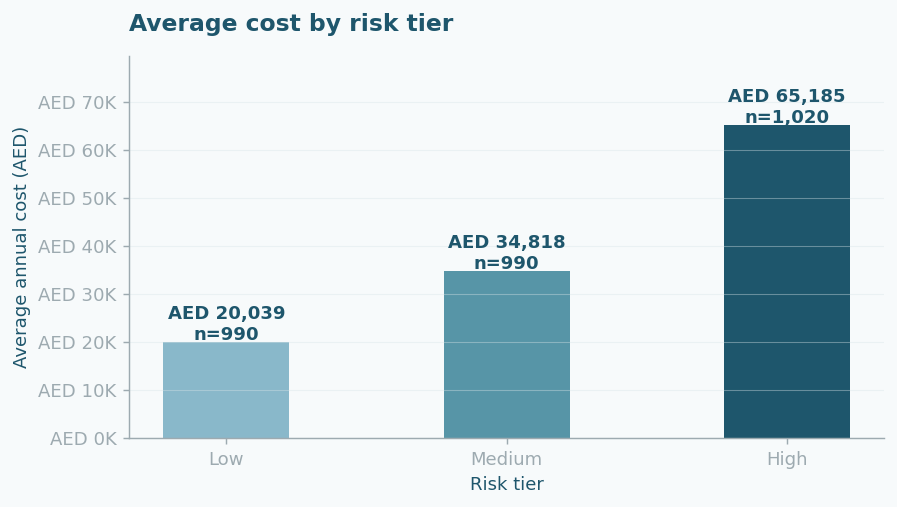

In [104]:
risk_cost = (df.groupby('risk_tier')['total_cost_aed']
               .agg(['mean', 'count'])
               .reindex(['Low', 'Medium', 'High']))

grade_colors = [TEAL_LIGHT, TEAL, NAVY]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(risk_cost.index, risk_cost['mean'],
              color=grade_colors, width=0.45, edgecolor='none')

for bar, (tier, row) in zip(bars, risk_cost.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            row['mean'] + 500,
            f"AED {row['mean']:,.0f}\nn={int(row['count']):,}",
            ha='center', fontsize=10, color=NAVY, fontweight='bold')

ax.set_ylabel('Average annual cost (AED)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1000:.0f}K'))
ax.set_title('Average cost by risk tier', loc='left')
ax.set_xlabel('Risk tier')
ax.set_ylim(0, risk_cost['mean'].max() * 1.22)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/02_cost_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Total cost exposure by emirate

**Business question:** Which emirates represent the biggest financial risk to the insurer?

Total claims spend by emirate in AED — this drives budget allocation decisions,
network investment priorities, and where care management programmes should be
physically deployed across the UAE.

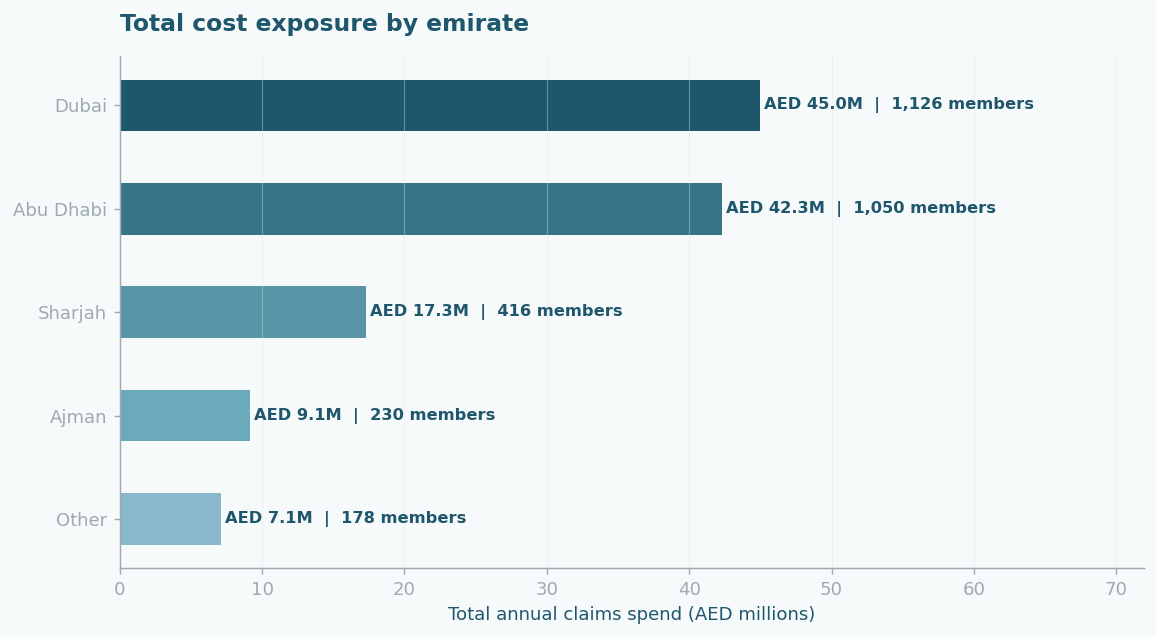

In [105]:
em_cost = (df.groupby('emirate')
             .agg(
                 total_cost = ('total_cost_aed', 'sum'),
                 members    = ('member_id', 'count'),
             )
             .sort_values('total_cost', ascending=True))

# Graded colours — darkest for highest, lightest for lowest
grade_colors = [TEAL_LIGHT, '#6AAABB', TEAL, TEAL_DARK, NAVY]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(em_cost.index, em_cost['total_cost'] / 1_000_000,
               color=grade_colors, height=0.5, edgecolor='none')

for bar, (idx, row) in zip(bars, em_cost.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"AED {row['total_cost']/1_000_000:.1f}M  |  {row['members']:,} members",
            va='center', fontsize=9, color=NAVY, fontweight='bold')

ax.set_xlabel('Total annual claims spend (AED millions)')
ax.set_title('Total cost exposure by emirate', loc='left')
ax.set_xlim(0, em_cost['total_cost'].max() / 1_000_000 * 1.6)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/03_total_cost_by_emirate.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4 — High-cost member rate and ER utilisation by payer

**Business question:** Which payers carry the highest proportion of high-cost members
and are their members driving more ER visits?

Average cost alone is too similar across payers to be meaningful.
Instead this chart shows the % of each payer's members flagged as high-cost (top 20%),
paired with their average ER visits — two metrics that directly impact a payer's
loss ratio and are used in UAE contract renegotiations.

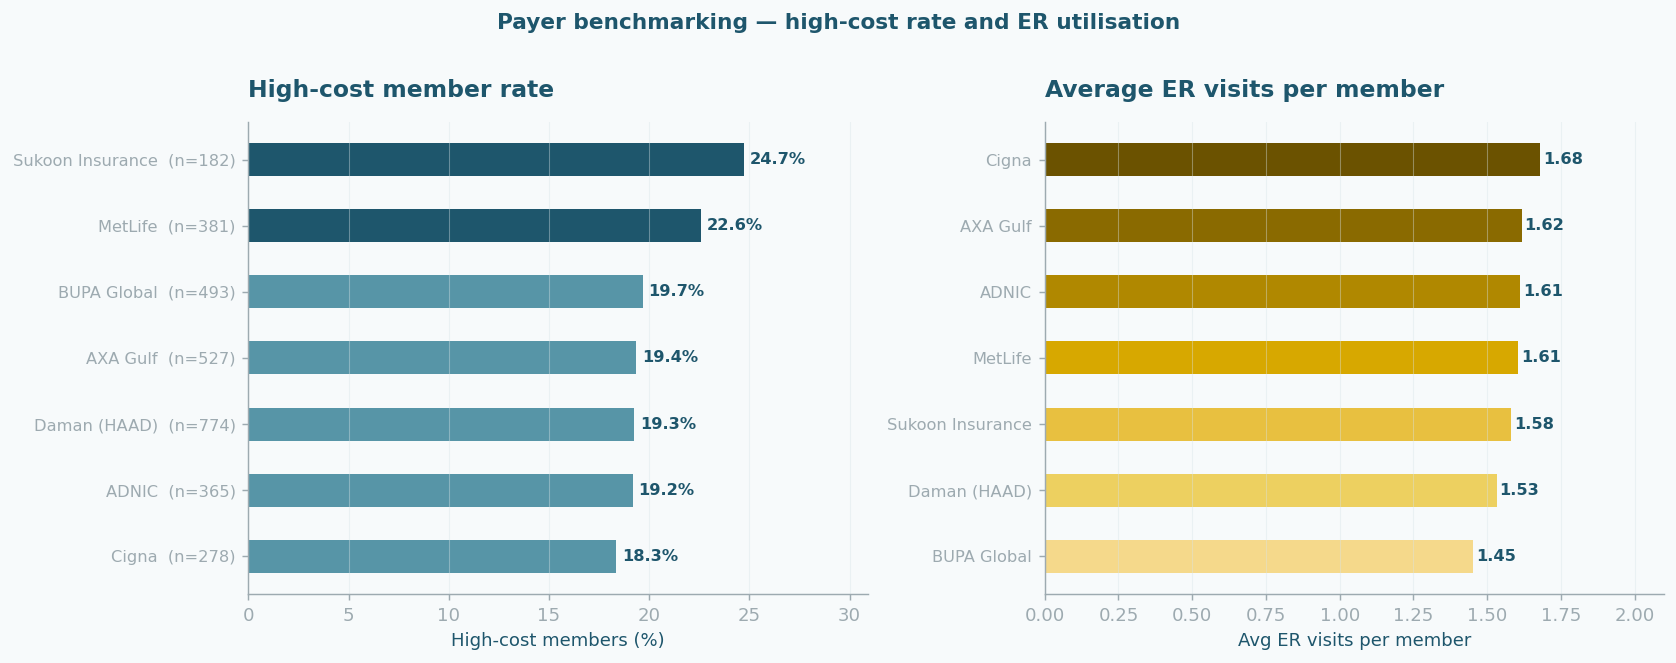

In [106]:
payer_stats = (df.groupby('payer')
                 .agg(
                     high_cost_pct = ('high_cost_flag', 'mean'),
                     avg_er        = ('er_visits', 'mean'),
                     members       = ('member_id', 'count')
                 )
                 .reset_index())

payer_stats['high_cost_pct'] *= 100
payer_stats = payer_stats.sort_values('high_cost_pct', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: High-cost member rate ───────────────────────────────
bars = ax1.barh(range(len(payer_stats)), payer_stats['high_cost_pct'],
                color=[NAVY if v > 20 else TEAL for v in payer_stats['high_cost_pct']],
                height=0.5, edgecolor='none')

for bar, (_, row) in zip(bars, payer_stats.iterrows()):
    ax1.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{row['high_cost_pct']:.1f}%",
             va='center', fontsize=9, color=NAVY, fontweight='bold')

ax1.set_yticks(range(len(payer_stats)))
ax1.set_yticklabels([f"{r['payer']}  (n={r['members']:,})"
                     for _, r in payer_stats.iterrows()], fontsize=9)
ax1.set_xlabel('High-cost members (%)')
ax1.set_title('High-cost member rate', loc='left')
ax1.set_xlim(0, payer_stats['high_cost_pct'].max() * 1.25)
ax1.grid(axis='x', alpha=0.4)

# ── Right: Average ER visits — graded amber ───────────────────
payer_er = payer_stats.sort_values('avg_er', ascending=True).reset_index(drop=True)
n = len(payer_er)
amber_grades = [AMBER_LIGHT, '#EDD060', AMBER_MID, AMBER, AMBER_DARK, AMBER_DARKER,
                '#6B5200'][:n]

bars2 = ax2.barh(range(n), payer_er['avg_er'],
                 color=amber_grades,
                 height=0.5, edgecolor='none')

for bar, (_, row) in zip(bars2, payer_er.iterrows()):
    ax2.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f"{row['avg_er']:.2f}",
             va='center', fontsize=9, color=NAVY, fontweight='bold')

ax2.set_yticks(range(n))
ax2.set_yticklabels([r['payer'] for _, r in payer_er.iterrows()], fontsize=9)
ax2.set_xlabel('Avg ER visits per member')
ax2.set_title('Average ER visits per member', loc='left')
ax2.set_xlim(0, payer_er['avg_er'].max() * 1.25)
ax2.grid(axis='x', alpha=0.4)

fig.suptitle('Payer benchmarking — high-cost rate and ER utilisation',
             fontsize=12, fontweight='bold', color=NAVY, x=0.5, y=1.01)

plt.tight_layout()
plt.savefig('../outputs/04_payer_benchmarking.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5 — BMI vs annual cost (coloured by risk tier)

**Business question:** Is BMI a reliable predictor of claims cost in this cohort?

Each dot is one member, coloured by risk tier. The amber trend line confirms
a positive relationship — higher BMI consistently associates with higher cost.
This validates BMI as a feature in the predictive model (Step 4).

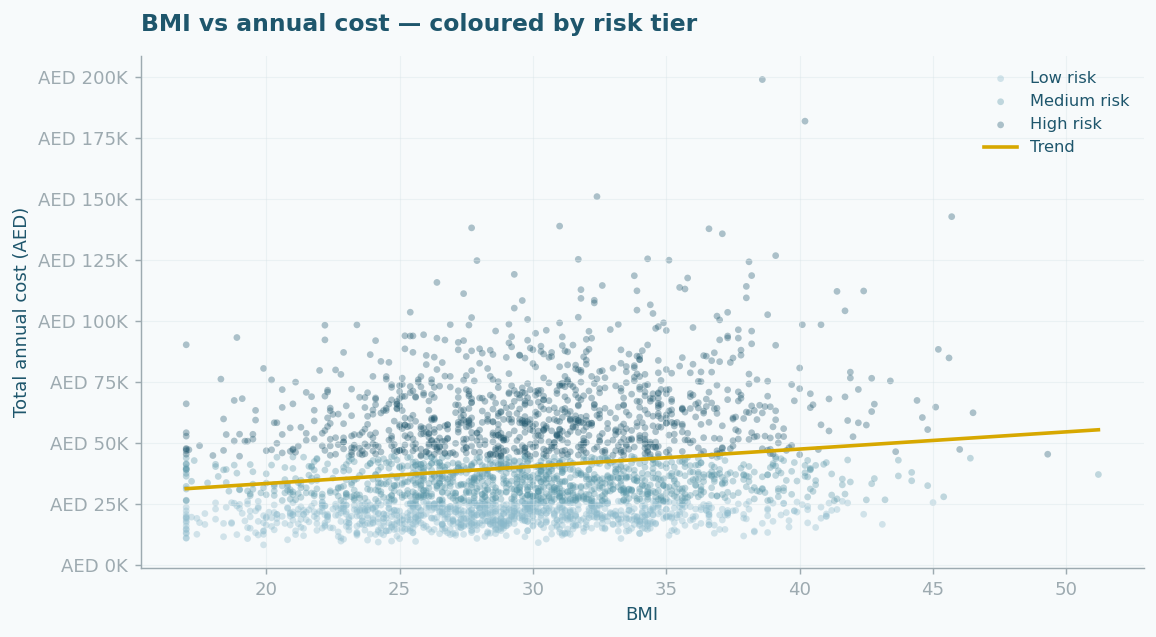

In [107]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_colors = {'Low': TEAL_LIGHT, 'Medium': TEAL, 'High': NAVY}
for tier, col in tier_colors.items():
    sub = df[df['risk_tier'] == tier]
    ax.scatter(sub['bmi'], sub['total_cost_aed'],
               alpha=0.35, s=14, color=col, label=f'{tier} risk', edgecolors='none')
z = np.polyfit(df['bmi'], df['total_cost_aed'], 1)
p = np.poly1d(z)
xline = np.linspace(df['bmi'].min(), df['bmi'].max(), 200)
ax.plot(xline, p(xline), color=AMBER, linewidth=2, label='Trend')
ax.set_xlabel('BMI')
ax.set_ylabel('Total annual cost (AED)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1000:.0f}K'))
ax.set_title('BMI vs annual cost — coloured by risk tier', loc='left')
ax.legend(framealpha=0, fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/05_bmi_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6 — Age distribution by chronic condition

**Business question:** Do different conditions affect different age groups?

Understanding the age profile of each condition helps insurers design age-banded
premiums and target wellness programmes at the right demographic.
Cardiac and comorbid conditions are expected to skew older.

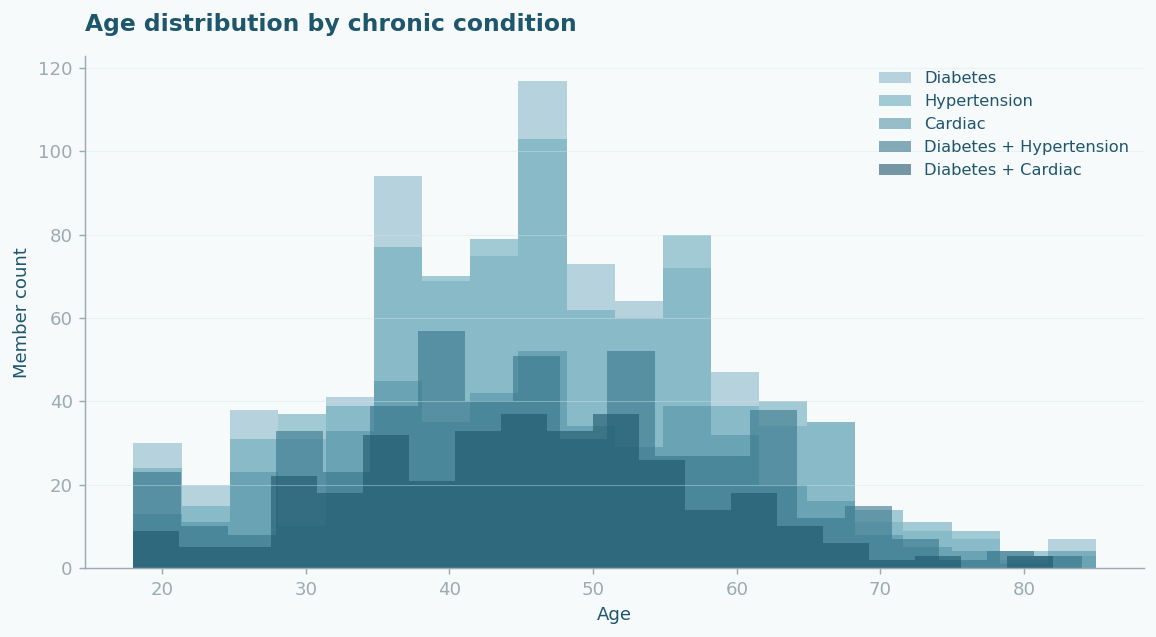

In [108]:
fig, ax = plt.subplots(figsize=(9, 5))

conditions_order = ['Diabetes', 'Hypertension', 'Cardiac',
                    'Diabetes + Hypertension', 'Diabetes + Cardiac']
grade_colors = [TEAL_LIGHT, '#6AAABB', TEAL, TEAL_DARK, NAVY]

for cond, col in zip(conditions_order, grade_colors):
    sub = df[df['condition'] == cond]['age']
    ax.hist(sub, bins=20, alpha=0.6, color=col, label=cond, edgecolor='none')

ax.set_xlabel('Age')
ax.set_ylabel('Member count')
ax.set_title('Age distribution by chronic condition', loc='left')
ax.legend(framealpha=0, fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/06_age_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 7 — ER utilisation vs annual cost

**Business question:** Do high ER users drive disproportionately higher costs?

Amber dots = top 20% high-cost members. Teal dots = standard cost members.
ER visits are one of the most controllable cost levers in health insurance —
members with 3+ visits per year are prime candidates for case management programmes.

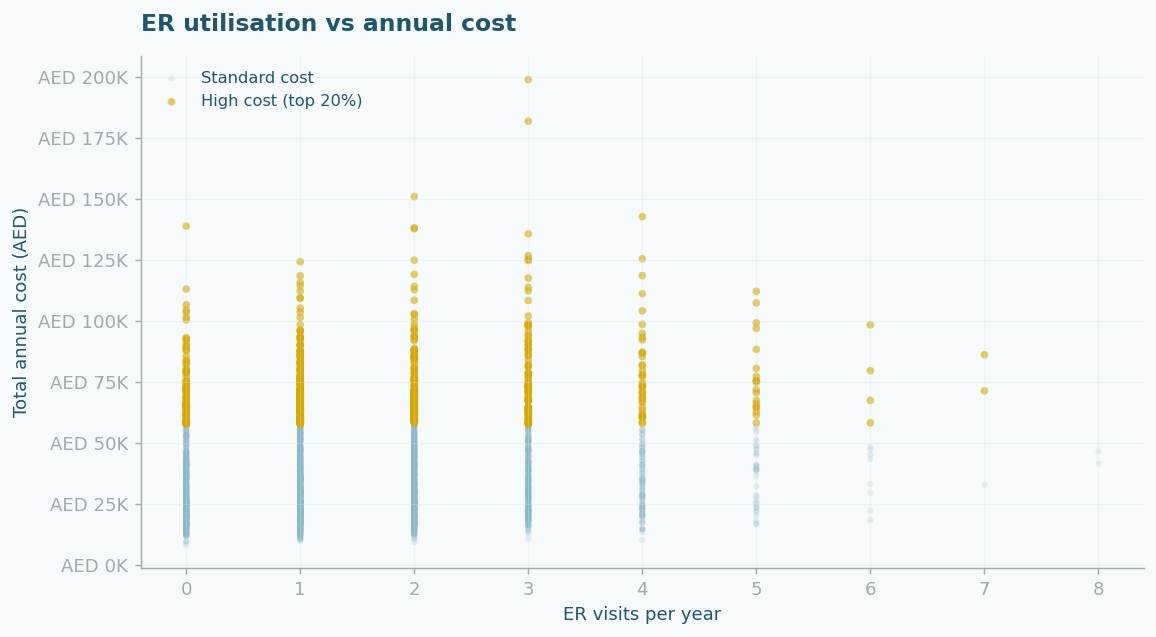

In [109]:
fig, ax = plt.subplots(figsize=(9, 5))

low  = df[df['high_cost_flag'] == 0]
high = df[df['high_cost_flag'] == 1]

ax.scatter(low['er_visits'], low['total_cost_aed'],
           alpha=0.2, s=12, color=TEAL_LIGHT, edgecolors='none', label='Standard cost')
ax.scatter(high['er_visits'], high['total_cost_aed'],
           alpha=0.6, s=18, color=AMBER, edgecolors='none', label='High cost (top 20%)')

ax.set_xlabel('ER visits per year')
ax.set_ylabel('Total annual cost (AED)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1000:.0f}K'))
ax.set_title('ER utilisation vs annual cost', loc='left')
ax.legend(framealpha=0, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/07_er_visits_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 8 — Cost breakdown by care type

**Business question:** Where is the money going — pharmacy, procedures, or consultations?

Understanding the split between care types helps insurers target cost reduction programmes.
A pharmacy-heavy portfolio suggests medication management opportunities.
A procedure-heavy portfolio points to utilisation management and pre-authorisation controls.

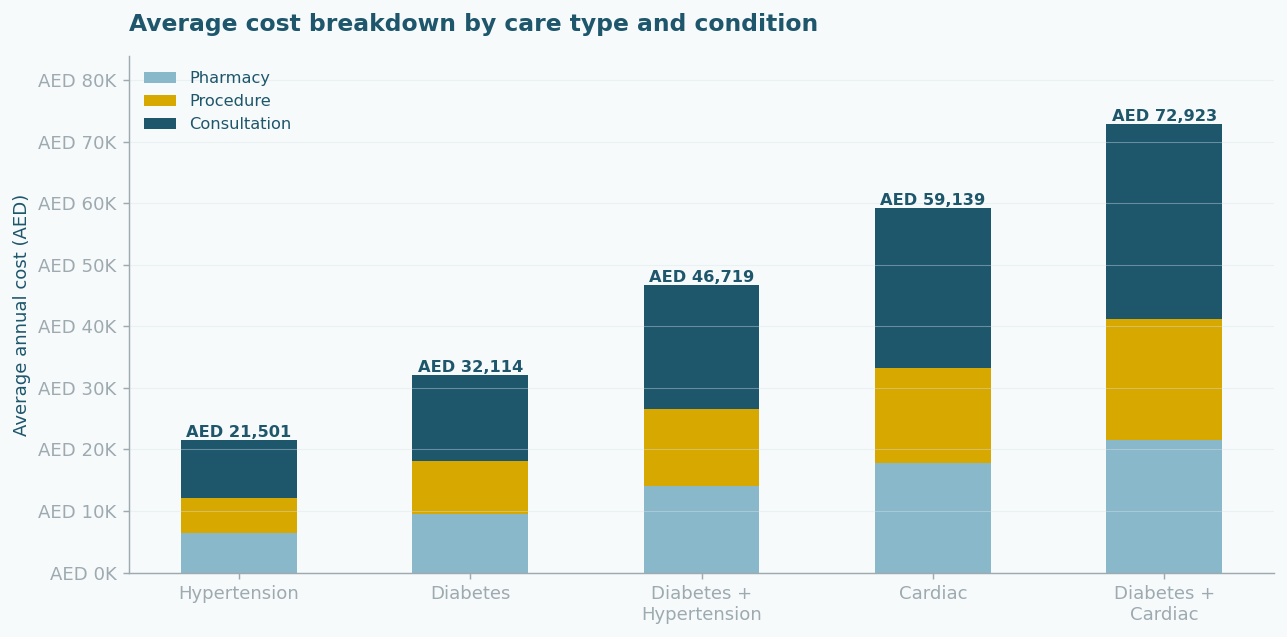

In [133]:
care_cost = df[['condition', 'pharmacy_cost_aed', 'procedure_cost_aed', 'consultation_cost_aed']]\
              .groupby('condition').mean()\
              .reindex(['Hypertension', 'Diabetes', 'Diabetes + Hypertension',
                        'Cardiac', 'Diabetes + Cardiac'])

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.5
x = range(len(care_cost))

ax.bar(x, care_cost['pharmacy_cost_aed'],
       color=TEAL_LIGHT, width=bar_width, edgecolor='none', label='Pharmacy')
ax.bar(x, care_cost['procedure_cost_aed'],
       bottom=care_cost['pharmacy_cost_aed'],
       color=AMBER, width=bar_width, edgecolor='none', label='Procedure')
ax.bar(x, care_cost['consultation_cost_aed'],
       bottom=care_cost['pharmacy_cost_aed'] + care_cost['procedure_cost_aed'],
       color=NAVY, width=bar_width, edgecolor='none', label='Consultation')

for i, (_, row) in enumerate(care_cost.iterrows()):
    total = row['pharmacy_cost_aed'] + row['procedure_cost_aed'] + row['consultation_cost_aed']
    ax.text(i, total + 500, f"AED {total:,.0f}",
            ha='center', fontsize=9, color=NAVY, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(['Hypertension', 'Diabetes', 'Diabetes +\nHypertension',
                    'Cardiac', 'Diabetes +\nCardiac'], rotation=0, ha='center')
ax.set_ylabel('Average annual cost (AED)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1000:.0f}K'))
ax.set_title('Average cost breakdown by care type and condition', loc='left')
ax.legend(framealpha=0, fontsize=9)
ax.set_ylim(0, care_cost.sum(axis=1).max() * 1.15)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/08_cost_by_care_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 9 — High-cost member rate by condition

**Business question:** Which conditions produce the most high-cost members (top 20% of spend)?

The dashed line is the portfolio average (20%). Conditions above it are generating
disproportionately more high-cost members — these are the priority intervention
cohorts for any UAE insurer or care management team.

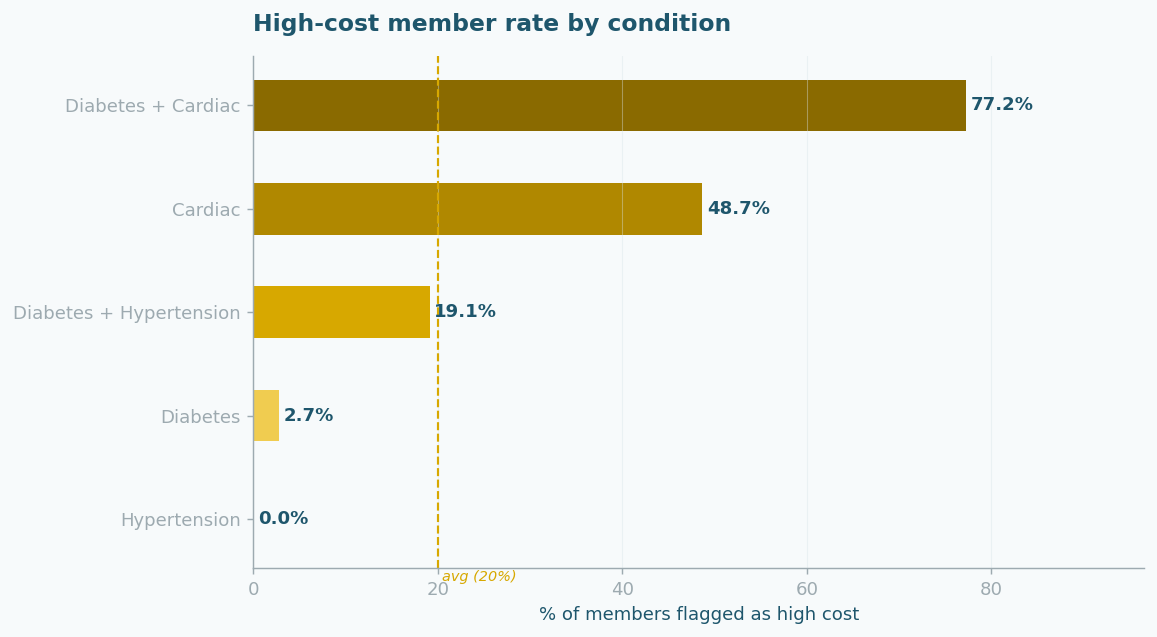

In [125]:
hcf = (df.groupby('condition')['high_cost_flag']
         .mean()
         .mul(100)
         .sort_values(ascending=True))

grade_colors = ['#FAE9A0', '#F0CC50', '#D7A800', '#B08800', '#8A6A00']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(hcf.index, hcf.values,
               color=grade_colors, height=0.5, edgecolor='none')

for bar, val in zip(bars, hcf.values):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color=NAVY, fontweight='bold')

ax.axvline(20, color=AMBER, linewidth=1.2, linestyle='--')
ax.text(20.5, -0.6, 'avg (20%)', fontsize=8, color=AMBER, style='italic')
ax.set_xlabel('% of members flagged as high cost')
ax.set_title('High-cost member rate by condition', loc='left')
ax.set_xlim(0, hcf.max() * 1.25)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/10_highcost_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table — key metrics by condition

Consolidated view of all key metrics per condition: member count, average cost,
median cost, total cohort spend, high-cost percentage, and average utilisation.

Saved to `outputs/summary_by_condition.csv` for use in the Tableau dashboard.

In [112]:
summary = (df.groupby('condition')
             .agg(
                 members         = ('member_id', 'count'),
                 avg_cost_aed    = ('total_cost_aed', 'mean'),
                 median_cost_aed = ('total_cost_aed', 'median'),
                 total_cost_aed  = ('total_cost_aed', 'sum'),
                 high_cost_pct   = ('high_cost_flag', 'mean'),
                 avg_er_visits   = ('er_visits', 'mean'),
                 avg_inpatient   = ('inpatient_days', 'mean'),
             )
             .sort_values('avg_cost_aed', ascending=False)
             .round(1))

summary['high_cost_pct']  = (summary['high_cost_pct'] * 100).round(1)
summary['avg_cost_aed']   = summary['avg_cost_aed'].round(0).astype(int)
summary['total_cost_aed'] = summary['total_cost_aed'].round(0).astype(int)

summary.to_csv('../outputs/summary_by_condition.csv')
print("Saved to outputs/summary_by_condition.csv\n")
summary

Saved to outputs/summary_by_condition.csv



,members,avg_cost_aed,median_cost_aed,total_cost_aed,high_cost_pct,avg_er_visits,avg_inpatient
condition,,,,,,,
Diabetes + Cardiac,334,72923,69756.5,24356236,80.0,1.5,2.1
Cardiac,456,59139,56866.5,26967542,50.0,1.6,2.2
Diabetes + Hypertension,502,46719,45354.5,23452992,20.0,1.6,2.1
Diabetes,876,32114,30454.0,28131736,0.0,1.6,2.1
Hypertension,832,21501,20528.5,17889043,0.0,1.6,2.1
